[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter3_lecture_notebook.ipynb)

# Time Series Analysis — Chapter 3: Unit roots and ARIMA models

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Deterministic and stochastic trends; detrending a random walk.
- Spurious regression: a Monte Carlo and a real example.
- The Dickey–Fuller distributions, size and power; ADF, Phillips–Perron and KPSS on real series.
- Structural breaks: Perron and Zivot–Andrews.
- ARIMA for Romanian GDP: identification, AICc, diagnostics, forecasts; forecast intervals; automatic ARIMA; EUR/RON against the random walk; US GDP after 2007.
- References: Huang and Petukhina (2022), *Applied Time Series Analysis and Forecasting with Python*, Ch. 4–5; Hyndman and Athanasopoulos, *Forecasting: Principles and Practice* (3rd ed.), Ch. 9; Hamilton (1994), Ch. 15–17.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_3'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions and helpers used in the whole notebook

- ADF regression: $\Delta y_t = c + bt + \gamma y_{t-1} + \sum_{j=1}^{k}\delta_j\Delta y_{t-j} + \varepsilon_t$, $H_0$: $\gamma = 0$ (unit root); `adf_test(x, reg)` with `reg` = `'n'`, `'c'` or `'ct'`.
- Phillips–Perron: `pp_test(x, reg)`, the Dickey–Fuller $t$-ratio corrected with the Newey–West long-run variance.
- KPSS: `kpss_test(x, reg)`, $H_0$: stationarity; Zivot–Andrews: `za_test(x, reg)`.
- ARIMA: `arima_grid(y, d, pmax, qmax, trend)` returns AICc, BIC and convergence for each $(p, q)$.

In [5]:
import itertools
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss, zivot_andrews
from statsmodels.tsa.adfvalues import mackinnonp, mackinnoncrit
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.stats.diagnostic import acorr_ljungbox
SEED = 2026
GDP_SA = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')
GDP_START = '2000-01-01'
START = '2000-01-01'
BAND_COL = st.IDAred
CASES = {'n': 'no constant', 'c': 'constant', 'ct': 'constant and trend'}


def ro_gdp():
    """Romanian quarterly real GDP (Eurostat), seasonally and calendar adjusted, million EUR (2010 prices)."""
    return read_eurostat(*GDP_SA).rename('gdp')


def ro_hicp():
    """Romanian HICP (Eurostat, monthly, 2015 = 100)."""
    return read_eurostat(*HICP).rename('hicp')


def ro_inflation(start='2005-01-01'):
    """Romanian 12-month HICP inflation in %: 100 (ln P_t - ln P_{t-12})."""
    return (100 * np.log(ro_hicp()).diff(12)).dropna().loc[start:].rename('infl')


def us_gdp():
    """US quarterly real GDP (FRED GDPC1, billions of chained 2017 dollars, seasonally adjusted)."""
    return read_fred('GDPC1').rename('us_gdp')


def quarterly(s):
    """A quarterly series with a PeriodIndex (for statsmodels ARIMA forecasts with dates)."""
    s = s.copy()
    s.index = pd.PeriodIndex(s.index, freq='Q')
    return s


def monthly(s):
    s = s.copy()
    s.index = pd.PeriodIndex(s.index, freq='M')
    return s


def sample_acf(x, nlags=20):
    """Sample ACF rho(1..nlags) with the divisor T."""
    return acf(np.asarray(x, float), nlags=nlags, fft=True)[1:]


def sample_pacf(x, nlags=20):
    return pacf(np.asarray(x, float), nlags=nlags, method='ywm')[1:]


def acf_bars(ax, r, T, color=st.MainBlue, label='sample ACF', band=True):
    """ACF as bars at lags 1..len(r), with the +-1.96/sqrt(T) bands."""
    lags = np.arange(1, len(r) + 1)
    ax.bar(lags, r, width=0.55, color=color, label=label)
    if band:
        b = 1.96 / np.sqrt(T)
        ax.axhline(b, color=BAND_COL, ls='--', lw=0.9, label=r'$\pm 1.96/\sqrt{T}$')
        ax.axhline(-b, color=BAND_COL, ls='--', lw=0.9, label='_nolegend_')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xlim(0.3, len(r) + 0.7)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def years_axis(ax, step=5):
    import matplotlib.dates as mdates
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


def adf_test(x, reg='c', autolag='AIC', maxlag=None):
    """Augmented Dickey-Fuller test: statistic, MacKinnon p-value, number of lags (chosen by AIC up to
    12 (T/100)^(1/4) by default), observations used, 5% critical value."""
    x = np.asarray(pd.Series(x).dropna(), float)
    r = adfuller(x, regression=reg, autolag=autolag, maxlag=maxlag)
    return {'stat': float(r[0]), 'p': float(r[1]), 'lags': int(r[2]), 'nobs': int(r[3]), 'crit5': float(r[4]['5%']),
            'crit1': float(r[4]['1%']), 'crit10': float(r[4]['10%'])}


def pp_test(x, reg='c', lags=None):
    """Phillips-Perron Z_tau test: the Dickey-Fuller regression without lagged differences; the t-statistic is
    corrected with the Newey-West long-run variance of the residuals (Bartlett weights, 12 (T/100)^(1/4) lags).
    Same null hypothesis (unit root) and the same MacKinnon critical values as the ADF test."""
    y = np.asarray(pd.Series(x).dropna(), float)
    dy, ylag = np.diff(y), y[:-1]
    n = len(dy)
    cols = [ylag]
    if reg in ('c', 'ct'):
        cols.append(np.ones(n))
    if reg == 'ct':
        cols.append(np.arange(1, n + 1, dtype=float))
    X = np.column_stack(cols)
    beta, *_ = np.linalg.lstsq(X, dy, rcond=None)
    u = dy - X @ beta
    k = X.shape[1]
    s2 = u @ u / (n - k)
    se = np.sqrt(s2 * np.linalg.inv(X.T @ X)[0, 0])
    t = beta[0] / se
    L = int(np.ceil(12 * (n / 100) ** 0.25)) if lags is None else lags
    g0 = u @ u / n
    lam2 = g0 + 2 * sum((1 - j / (L + 1)) * (u[j:] @ u[:-j]) / n for j in range(1, L + 1))
    z = np.sqrt(g0 / lam2) * t - 0.5 * (lam2 - g0) / np.sqrt(lam2) * n * se / np.sqrt(s2)
    return {'stat': float(z), 'p': float(mackinnonp(z, regression=reg, N=1)), 'lags': L,
            'crit5': float(mackinnoncrit(N=1, regression=reg, nobs=n)[1])}


def kpss_test(x, reg='c'):
    """KPSS test of stationarity (around a constant, reg='c', or a linear trend, reg='ct'); the p-value is
    interpolated from the table of Kwiatkowski et al. (1992) and lies between 0.01 and 0.10."""
    x = np.asarray(pd.Series(x).dropna(), float)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        r = kpss(x, regression=reg, nlags='auto')
    return {'stat': float(r[0]), 'p': float(r[1]), 'lags': int(r[2]), 'crit5': float(r[3]['5%'])}


def za_test(x, reg='c'):
    """Zivot-Andrews test: unit root against stationarity with one break (in the level, reg='c'; in the trend,
    reg='t'; in both, reg='ct') at an unknown date chosen to give the most negative t-statistic."""
    s = pd.Series(x).dropna()
    r = zivot_andrews(np.asarray(s, float), regression=reg, autolag='AIC')
    return {'stat': float(r[0]), 'p': float(r[1]), 'crit5': float(r[2]['5%']), 'lags': int(r[3]),
            'break': str(s.index[int(r[4])])[:10]}


def verdict(adf, kp, alpha=0.05):
    """ADF and KPSS together: 'I(0)', 'I(1)', or 'conflict' (both reject) / 'inconclusive' (neither rejects)."""
    a, k = adf['p'] < alpha, kp['stat'] > kp['crit5']
    return {(True, False): 'I(0)', (False, True): 'I(1)', (True, True): 'conflict', (False, False): 'inconclusive'}[(a, k)]


def df_tau_batch(y, reg='c'):
    """Dickey-Fuller t-statistics (no lagged differences) for many paths at once: y has shape (R, T+1)."""
    y = np.asarray(y, float)
    dy, ylag = np.diff(y, axis=1), y[:, :-1]
    n = dy.shape[1]
    D = {'n': np.zeros((n, 0)), 'c': np.ones((n, 1)), 'ct': np.column_stack([np.ones(n), np.arange(1, n + 1)])}[reg]
    if D.shape[1]:
        P = D @ np.linalg.pinv(D)
        ylag = ylag - ylag @ P.T
        dy = dy - dy @ P.T
    sxx = np.sum(ylag ** 2, axis=1)
    g = np.sum(ylag * dy, axis=1) / sxx
    u = dy - g[:, None] * ylag
    s2 = np.sum(u ** 2, axis=1) / (n - 1 - D.shape[1])
    return g / np.sqrt(s2 / sxx)


def random_walks(R, T, rng, drift=0.0, phi=1.0, sigma=1.0):
    """R paths of y_t = drift + phi y_{t-1} + e_t, y_0 = 0, t = 1..T (returned with y_0: shape (R, T+1))."""
    e = rng.normal(0, sigma, (R, T))
    y = np.zeros((R, T + 1))
    if phi == 1.0:
        y[:, 1:] = np.cumsum(drift + e, axis=1)
    else:
        for t in range(1, T + 1):
            y[:, t] = drift + phi * y[:, t - 1] + e[:, t - 1]
    return y


def ljung_box(x, m=10, df=0):
    """Ljung-Box Q*(m) with chi-square(m - df) p-value (df = number of estimated ARMA coefficients)."""
    t = acorr_ljungbox(np.asarray(pd.Series(x).dropna(), float), lags=[m], model_df=df, return_df=True).iloc[0]
    return {'lb': float(t['lb_stat']), 'lb_p': float(t['lb_pvalue']), 'm': m, 'df': m - df}


def arima_grid(y, d=1, pmax=2, qmax=2, trend='t'):
    """Fit ARIMA(p, d, q) for p <= pmax, q <= qmax (trend 't' = drift when d = 1, 'c' = mean when d = 0, 'n' = none);
    AICc, BIC and whether the optimiser converged."""
    out = {}
    for p, q in itertools.product(range(pmax + 1), range(qmax + 1)):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            m = ARIMA(y, order=(p, d, q), trend=trend).fit()
        out[(p, q)] = {'aicc': float(m.aicc), 'bic': float(m.bic), 'converged': bool(m.mle_retvals.get('converged', True))}
    return out


def best_order(grid):
    ok = {k: v for k, v in grid.items() if v['converged']}
    return min(ok, key=lambda k: ok[k]['aicc'])


def gdp_series(start=GDP_START):
    """100 ln of Romanian real GDP (quarterly, SA), with a quarterly PeriodIndex."""
    return quarterly(100 * np.log(ro_gdp().loc[start:])).rename('gdp')


def gdp_order():
    """The ARIMA(p,1,q) with drift chosen by AICc (p, q <= 2, converged fits only) for 100 ln GDP since 2000."""
    p, q = best_order(arima_grid(gdp_series()))
    return (p, 1, q)


def gdp_fit(order=None):
    order = order or gdp_order()
    y = gdp_series()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return ARIMA(y, order=order, trend='t').fit()


def psi_weights(ar=(), ma=(), d=0, n=30):
    """psi_j (j = 0..n-1) of phi(L)(1 - L)^d y_t = theta(L) e_t: the forecast error of horizon h has variance
    sigma^2 (psi_0^2 + ... + psi_{h-1}^2)."""
    a = np.r_[1, -np.asarray(ar, float)]
    for _ in range(d):
        a = np.convolve(a, [1, -1])
    return ArmaProcess(a, np.r_[1, np.asarray(ma, float)]).impulse_response(n)


def ols_summary(y, x):
    from statsmodels.stats.stattools import durbin_watson
    d = pd.concat([y, x], axis=1).dropna()
    m = sm.OLS(d.iloc[:, 0], sm.add_constant(d.iloc[:, 1])).fit()
    return {'n': int(len(d)), 'b': float(m.params.iloc[1]), 't': float(m.tvalues.iloc[1]), 'p': float(m.pvalues.iloc[1]),
            'r2': float(m.rsquared), 'dw': float(durbin_watson(m.resid))}, m

## 1. Deterministic and stochastic trends

- Four trending series; a trend-stationary and a difference-stationary series with the same shocks; a random walk detrended by a straight line.

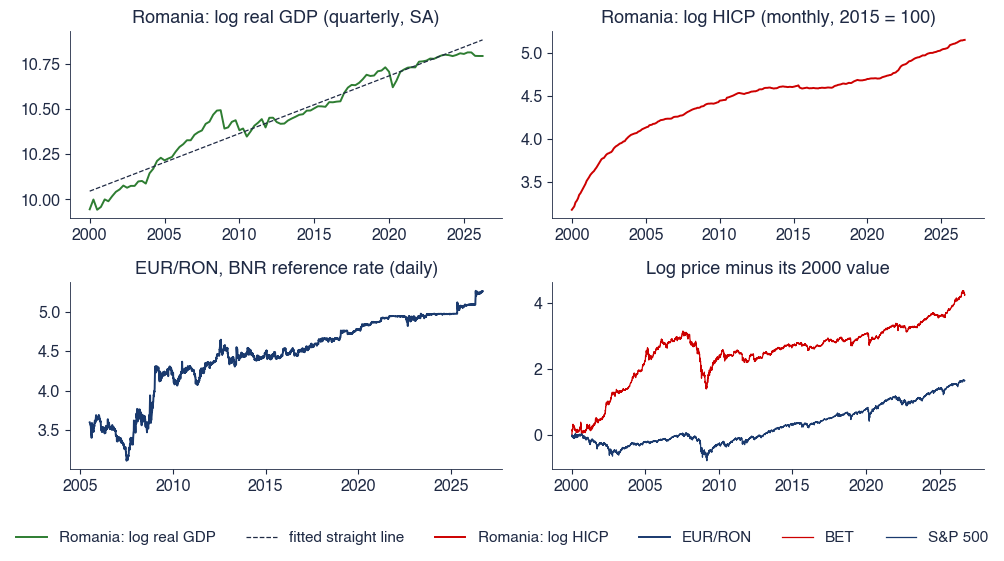

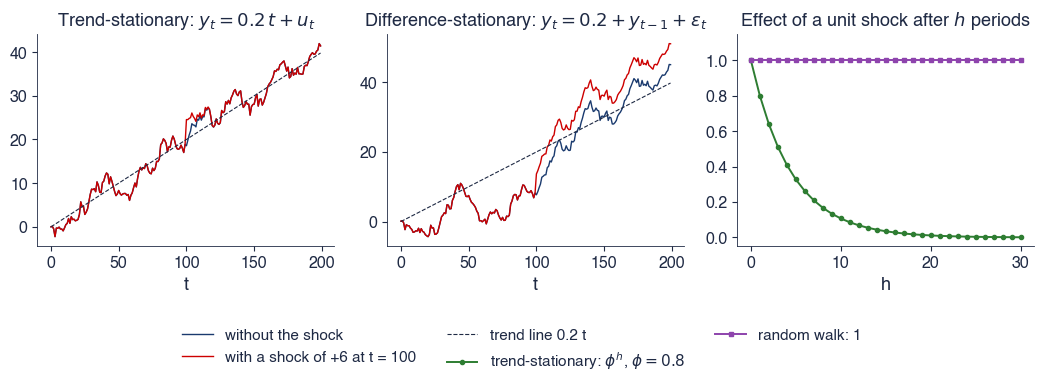

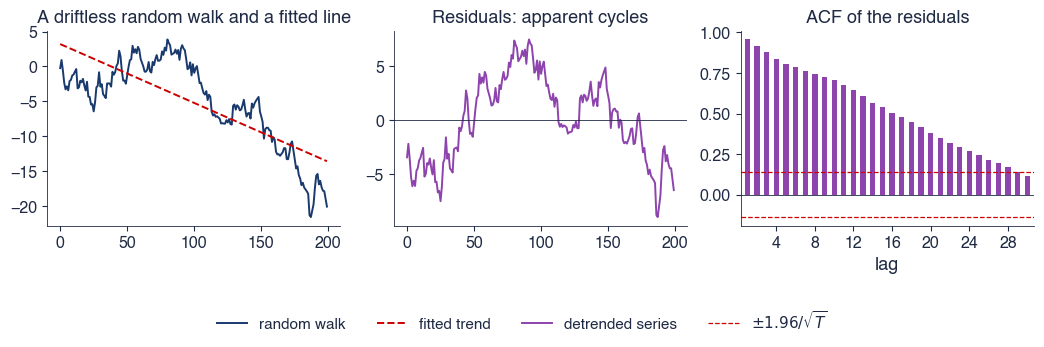

{'r2': 0.6131072327015378,
 'tstat': -17.71354599604193,
 'res_r1': 0.9570616564985682,
 'res_first_neg': 37,
 'mc_reject': 0.904,
 'mc_r2_median': 0.44459079886715885,
 'R': 2000,
 'T': 200}

In [6]:
def fig_four_series(save_it=True):
    """Four trending series: Romanian real GDP (log), Romanian HICP (log), EUR/RON, BET and S&P 500 log prices."""
    g = np.log(ro_gdp().loc[GDP_START:])
    h = np.log(ro_hicp().loc['2000-01-01':])
    fx = load_close('eurron')
    bet = np.log(load_close('bet', start=START))
    sp = np.log(load_close('sp500', start=START))
    fig, ax = plt.subplots(2, 2, figsize=(10.0, 5.2))
    tt = np.arange(len(g))
    b = np.polyfit(tt, g.values, 1)
    ax[0, 0].plot(g.index, g, color=st.Forest, label='Romania: log real GDP')
    ax[0, 0].plot(g.index, np.polyval(b, tt), color=st.DarkText, ls='--', lw=0.9, label='fitted straight line')
    ax[0, 0].set_title('Romania: log real GDP (quarterly, SA)')
    ax[0, 1].plot(h.index, h, color=st.IDAred, label='Romania: log HICP')
    ax[0, 1].set_title('Romania: log HICP (monthly, 2015 = 100)')
    ax[1, 0].plot(fx.index, fx, color=st.MainBlue, label='EUR/RON')
    ax[1, 0].set_title('EUR/RON, BNR reference rate (daily)')
    ax[1, 1].plot(bet.index, bet - bet.iloc[0], color=st.COL['bet'], lw=0.9, label='BET')
    ax[1, 1].plot(sp.index, sp - sp.iloc[0], color=st.COL['sp500'], lw=0.9, label='S&P 500')
    ax[1, 1].set_title('Log price minus its 2000 value')
    for a in ax.flat:
        years_axis(a, 5)
    st.fig_legend_bottom(fig, ncol=6, y=-0.01)
    plt.tight_layout()
    save('tsa_ch3_four_series', save_it)
    resid = g.values - np.polyval(b, tt)
    return {'gdp_growth_q': float(100 * b[0]), 'gdp_first': str(g.index[0])[:10], 'gdp_last': str(g.index[-1])[:10],
            'gdp_maxdev': float(100 * np.max(np.abs(resid))), 'hicp_ratio': float(np.exp(h.iloc[-1] - h.iloc[0])),
            'hicp_first': str(h.index[0])[:10], 'hicp_last': str(h.index[-1])[:10],
            'fx_first': float(fx.iloc[0]), 'fx_last': float(fx.iloc[-1]), 'fx_d0': str(fx.index[0])[:10],
            'bet_logchg': float(bet.iloc[-1] - bet.iloc[0]), 'sp_logchg': float(sp.iloc[-1] - sp.iloc[0]),
            'end': str(sp.index[-1])[:10]}


def fig_ts_ds(T=200, phi=0.8, drift=0.2, shock=6.0, t0=100, save_it=True):
    """Trend-stationary y_t = drift t + u_t (u_t AR(1)) and difference-stationary y_t = drift + y_{t-1} + e_t,
    driven by the same shocks, with and without one large shock at t0; and the response of y_{t0+h} to a unit shock."""
    rng = np.random.default_rng(SEED + 1)
    e = rng.normal(0, 1, T)
    e2 = e.copy()
    e2[t0] += shock
    t = np.arange(T)

    def paths(eps):
        u = np.zeros(T)
        for i in range(1, T):
            u[i] = phi * u[i - 1] + eps[i]
        return drift * t + u, drift * t + np.cumsum(eps)
    ts0, ds0 = paths(e)
    ts1, ds1 = paths(e2)
    fig, ax = plt.subplots(1, 3, figsize=(10.6, 3.2))
    ax[0].plot(t, ts0, color=st.MainBlue, lw=1.0, label='without the shock')
    ax[0].plot(t, ts1, color=st.IDAred, lw=1.0, label=f'with a shock of +{shock:.0f} at t = {t0}')
    ax[0].plot(t, drift * t, color=st.DarkText, ls='--', lw=0.8, label='trend line 0.2 t')
    ax[0].set_title('Trend-stationary: $y_t = 0.2\\,t + u_t$')
    ax[1].plot(t, ds0, color=st.MainBlue, lw=1.0)
    ax[1].plot(t, ds1, color=st.IDAred, lw=1.0)
    ax[1].plot(t, drift * t, color=st.DarkText, ls='--', lw=0.8)
    ax[1].set_title('Difference-stationary: $y_t = 0.2 + y_{t-1} + \\varepsilon_t$')
    h = np.arange(0, 31)
    ax[2].plot(h, phi ** h, 'o-', ms=3, color=st.Forest, label=r'trend-stationary: $\phi^h$, $\phi = 0.8$')
    ax[2].plot(h, np.ones_like(h, dtype=float), 's-', ms=3, color=st.Purple, label='random walk: 1')
    ax[2].set_title('Effect of a unit shock after $h$ periods')
    ax[2].set_xlabel('h')
    ax[2].set_ylim(-0.05, 1.15)
    for a in ax[:2]:
        a.set_xlabel('t')
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch3_ts_ds', save_it)
    return {'gap_ts_end': float(ts1[-1] - ts0[-1]), 'gap_ds_end': float(ds1[-1] - ds0[-1]), 'phi10': phi ** 10,
            'phi20': phi ** 20}


def fig_detrend(T=200, R=2000, save_it=True):
    """A random walk detrended with a straight line: the residuals look like regular cycles (Nelson and Kang, 1981);
    Monte Carlo: R^2 of the trend and rejection rate of 'no trend' (|t| > 1.96) on driftless random walks."""
    rng = np.random.default_rng(SEED + 2)
    y = np.cumsum(rng.normal(size=T))
    t = np.arange(T)
    X = sm.add_constant(t)
    m = sm.OLS(y, X).fit()
    res = m.resid
    fig, ax = plt.subplots(1, 3, figsize=(10.6, 3.0))
    ax[0].plot(t, y, color=st.MainBlue, label='random walk')
    ax[0].plot(t, m.fittedvalues, color=st.IDAred, ls='--', label='fitted trend')
    ax[0].set_title('A driftless random walk and a fitted line')
    ax[1].plot(t, res, color=st.Purple, label='detrended series')
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    ax[1].set_title('Residuals: apparent cycles')
    acf_bars(ax[2], sample_acf(res, 30), T, color=st.Purple, label='_nolegend_')
    ax[2].set_title('ACF of the residuals')
    ax[2].set_xlabel('lag')
    st.fig_legend_bottom(fig, ncol=5, y=-0.01)
    plt.tight_layout()
    save('tsa_ch3_detrend', save_it)
    # Monte Carlo: regression of a driftless random walk on a time trend
    Y = np.cumsum(rng.normal(size=(R, T)), axis=1)
    tc = t - t.mean()
    b = (Y - Y.mean(axis=1, keepdims=True)) @ tc / (tc @ tc)
    fit = Y.mean(axis=1, keepdims=True) + b[:, None] * tc[None, :]
    u = Y - fit
    s2 = np.sum(u ** 2, axis=1) / (T - 2)
    tstat = b / np.sqrt(s2 / (tc @ tc))
    r2 = 1 - np.sum(u ** 2, axis=1) / np.sum((Y - Y.mean(axis=1, keepdims=True)) ** 2, axis=1)
    rr = sample_acf(res, 60)
    neg = int(np.argmax(rr < 0)) + 1 if np.any(rr < 0) else 0
    return {'r2': float(m.rsquared), 'tstat': float(m.tvalues[1]), 'res_r1': float(rr[0]), 'res_first_neg': neg,
            'mc_reject': float(np.mean(np.abs(tstat) > 1.96)), 'mc_r2_median': float(np.median(r2)), 'R': R, 'T': T}


fig_four_series(save_it=False)
fig_ts_ds(save_it=False)
fig_detrend(save_it=False)

## 2. Spurious regression

- Independent random walks regressed on each other; Romanian HICP against the S&P 500.

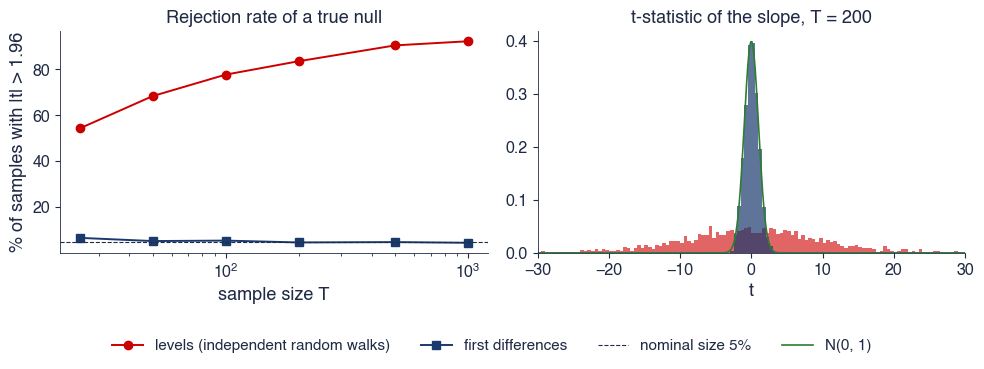

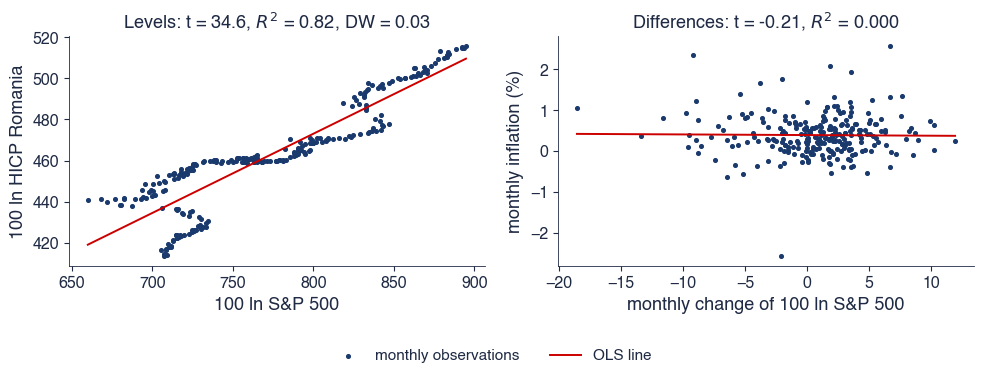

{'levels': {'n': 260,
  'b': 0.3861007651050161,
  't': 34.623048646176464,
  'p': 5.7509664360748786e-99,
  'r2': 0.8228940955205353,
  'dw': 0.027701499471287656},
 'differences': {'n': 259,
  'b': -0.0015528011573494444,
  't': -0.21339542896972993,
  'p': 0.8311877313816459,
  'r2': 0.00017715775005755496,
  'dw': 1.200748388662466},
 'first': '2005-01-01',
 'last': '2026-08-01'}

In [7]:
def spurious_mc(Ts=(25, 50, 100, 200, 500, 1000), R=2000):
    """Granger-Newbold experiment: regress y on x (with a constant), y and x independent random walks; rejection
    rate of |t| > 1.96, median R^2 and median Durbin-Watson, in levels and in first differences."""
    rng = np.random.default_rng(SEED + 3)
    out = {}
    tsamp = {}
    for T in Ts:
        res = {}
        x = np.cumsum(rng.normal(size=(R, T)), axis=1)
        y = np.cumsum(rng.normal(size=(R, T)), axis=1)
        for kind, (a, b) in {'levels': (y, x), 'differences': (np.diff(y, axis=1), np.diff(x, axis=1))}.items():
            n = a.shape[1]
            xc = b - b.mean(axis=1, keepdims=True)
            yc = a - a.mean(axis=1, keepdims=True)
            beta = np.sum(xc * yc, axis=1) / np.sum(xc ** 2, axis=1)
            u = yc - beta[:, None] * xc
            s2 = np.sum(u ** 2, axis=1) / (n - 2)
            t = beta / np.sqrt(s2 / np.sum(xc ** 2, axis=1))
            r2 = 1 - np.sum(u ** 2, axis=1) / np.sum(yc ** 2, axis=1)
            dw = np.sum(np.diff(u, axis=1) ** 2, axis=1) / np.sum(u ** 2, axis=1)
            res[kind] = {'reject': float(np.mean(np.abs(t) > 1.96)), 'r2': float(np.median(r2)), 'dw': float(np.median(dw)),
                         'abs_t_median': float(np.median(np.abs(t)))}
            if T == 200:
                tsamp[kind] = t
        out[T] = res
    return out, tsamp


def fig_spurious_mc(save_it=True):
    out, tsamp = spurious_mc()
    Ts = sorted(out)
    fig, ax = plt.subplots(1, 2, figsize=(10.0, 3.3))
    ax[0].plot(Ts, [100 * out[T]['levels']['reject'] for T in Ts], 'o-', color=st.IDAred, label='levels (independent random walks)')
    ax[0].plot(Ts, [100 * out[T]['differences']['reject'] for T in Ts], 's-', color=st.MainBlue, label='first differences')
    ax[0].axhline(5, color=st.DarkText, ls='--', lw=0.8, label='nominal size 5%')
    ax[0].set_xscale('log')
    ax[0].set_xlabel('sample size T')
    ax[0].set_ylabel('% of samples with |t| > 1.96')
    ax[0].set_title('Rejection rate of a true null')
    bins = np.linspace(-30, 30, 121)
    ax[1].hist(tsamp['levels'], bins=bins, density=True, color=st.IDAred, alpha=0.6, label='_nolegend_')
    ax[1].hist(tsamp['differences'], bins=bins, density=True, color=st.MainBlue, alpha=0.7, label='_nolegend_')
    xx = np.linspace(-30, 30, 400)
    ax[1].plot(xx, stats.norm.pdf(xx), color=st.Forest, lw=1.2, label='N(0, 1)')
    ax[1].set_xlim(-30, 30)
    ax[1].set_title('t-statistic of the slope, T = 200')
    ax[1].set_xlabel('t')
    st.fig_legend_bottom(fig, ncol=4, y=-0.01)
    plt.tight_layout()
    save('tsa_ch3_spurious_mc', save_it)
    return {str(T): v for T, v in out.items()}


def fig_spurious_real(save_it=True):
    """Romanian log HICP regressed on the log S&P 500 (month-end values, 2005 onwards): in levels and in differences."""
    h = np.log(ro_hicp()).rename('hicp')
    sp = np.log(load_close('sp500', start=START)).resample('MS').last().rename('sp500')
    d = pd.concat([h, sp], axis=1).dropna().loc['2005-01-01':]
    lev, ml = ols_summary(100 * d['hicp'], 100 * d['sp500'])
    dif, md = ols_summary(100 * d['hicp'].diff(), 100 * d['sp500'].diff())
    fig, ax = plt.subplots(1, 2, figsize=(10.0, 3.4))
    ax[0].scatter(100 * d['sp500'], 100 * d['hicp'], s=7, color=st.MainBlue, label='monthly observations')
    xs = np.linspace(100 * d['sp500'].min(), 100 * d['sp500'].max(), 50)
    ax[0].plot(xs, ml.params.iloc[0] + ml.params.iloc[1] * xs, color=st.IDAred, label='OLS line')
    ax[0].set_xlabel('100 ln S&P 500')
    ax[0].set_ylabel('100 ln HICP Romania')
    ax[0].set_title(f'Levels: t = {lev["t"]:.1f}, $R^2$ = {lev["r2"]:.2f}, DW = {lev["dw"]:.2f}')
    dd = d.diff().dropna() * 100
    ax[1].scatter(dd['sp500'], dd['hicp'], s=7, color=st.MainBlue)
    xs = np.linspace(dd['sp500'].min(), dd['sp500'].max(), 50)
    ax[1].plot(xs, md.params.iloc[0] + md.params.iloc[1] * xs, color=st.IDAred)
    ax[1].set_xlabel('monthly change of 100 ln S&P 500')
    ax[1].set_ylabel('monthly inflation (%)')
    ax[1].set_title(f'Differences: t = {dif["t"]:.2f}, $R^2$ = {dif["r2"]:.3f}')
    st.fig_legend_bottom(fig, ncol=2, y=-0.01)
    plt.tight_layout()
    save('tsa_ch3_spurious_real', save_it)
    return {'levels': lev, 'differences': dif, 'first': str(d.index[0])[:10], 'last': str(d.index[-1])[:10]}


fig_spurious_mc(save_it=False)
fig_spurious_real(save_it=False)

## 3. The Dickey–Fuller test

- Null distributions in three specifications; size and power; a worked example on Romanian GDP.

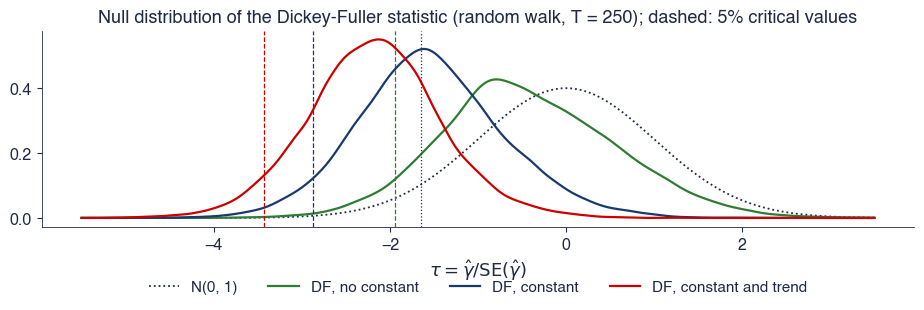

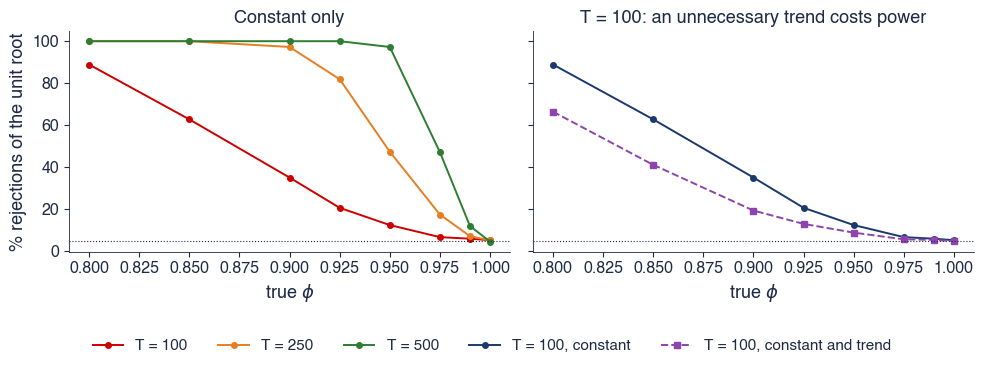

{'n': 105,
 'c': 97.8513661231785,
 'b': 0.06679456241209579,
 'gamma': -0.09613855989055675,
 'se': 0.04159079302290406,
 'tau': -2.3115346667617813,
 'phi': 0.9038614401094432,
 'crit5': -3.4531621209372636,
 'p': 0.42758057264113136,
 'maxlag': 13}

In [8]:
def fig_df_dist(T=250, R=20000, save_it=True):
    """Null distribution of the Dickey-Fuller t-statistic (random walk, T = 250) in the three specifications,
    against N(0, 1); MacKinnon (1996) 5% critical values."""
    rng = np.random.default_rng(SEED + 4)
    y = random_walks(R, T, rng)
    fig, ax = plt.subplots(figsize=(9.4, 3.4))
    xx = np.linspace(-5.5, 3.5, 400)
    ax.plot(xx, stats.norm.pdf(xx), color=st.DarkText, lw=1.3, ls=':', label='N(0, 1)')
    out = {}
    for reg, c in [('n', st.Forest), ('c', st.MainBlue), ('ct', st.IDAred)]:
        tau = df_tau_batch(y, reg)
        kde = stats.gaussian_kde(tau)
        ax.plot(xx, kde(xx), color=c, lw=1.6, label=f'DF, {CASES[reg]}')
        cv = mackinnoncrit(N=1, regression=reg, nobs=T)
        ax.axvline(cv[1], color=c, ls='--', lw=0.9)
        out[reg] = {'q05_sim': float(np.quantile(tau, 0.05)), 'q01_sim': float(np.quantile(tau, 0.01)),
                    'mean_sim': float(tau.mean()), 'crit5': float(cv[1]), 'crit1': float(cv[0]), 'crit10': float(cv[2]),
                    'p_below_normal': float(np.mean(tau < -1.645))}
    ax.axvline(-1.645, color=st.DarkText, ls=':', lw=0.9)
    ax.set_xlabel(r'$\tau = \hat\gamma/\mathrm{SE}(\hat\gamma)$')
    ax.set_title(f'Null distribution of the Dickey-Fuller statistic (random walk, T = {T}); dashed: 5% critical values')
    st.legend_outside_bottom(ax, ncol=4, y=-0.2)
    plt.tight_layout()
    save('tsa_ch3_df_dist', save_it)
    out['table'] = {str(n): {reg: [float(v) for v in mackinnoncrit(N=1, regression=reg, nobs=n)] for reg in ('n', 'c', 'ct')}
                    for n in (50, 100, 250, 500)}
    out['table']['inf'] = {reg: [float(v) for v in mackinnoncrit(N=1, regression=reg, nobs=np.inf)] for reg in ('n', 'c', 'ct')}
    return out


def fig_adf_power(R=2000, phis=(0.80, 0.85, 0.90, 0.925, 0.95, 0.975, 0.99, 1.0), Ts=(100, 250, 500), save_it=True):
    """Size and power of the Dickey-Fuller test (5%): rejection rate of H0 when y_t = phi y_{t-1} + e_t.
    Left: constant only, three sample sizes; right: T = 100, constant against constant and trend."""
    rng = np.random.default_rng(SEED + 5)
    power = {}
    for T in Ts:
        for reg in ('c', 'ct'):
            cv = mackinnoncrit(N=1, regression=reg, nobs=T)[1]
            for phi in phis:
                y = random_walks(R, T + 100, rng, phi=phi)[:, 100:]     # burn-in of 100 observations
                power[(T, reg, phi)] = float(np.mean(df_tau_batch(y, reg) < cv))
    fig, ax = plt.subplots(1, 2, figsize=(10.0, 3.3), sharey=True)
    for T, c in zip(Ts, [st.IDAred, st.Orange, st.Forest]):
        ax[0].plot(phis, [100 * power[(T, 'c', p)] for p in phis], 'o-', color=c, ms=4, label=f'T = {T}')
    ax[0].set_title('Constant only')
    for reg, c, mk in [('c', st.MainBlue, 'o-'), ('ct', st.Purple, 's--')]:
        ax[1].plot(phis, [100 * power[(100, reg, p)] for p in phis], mk, color=c, ms=4, label=f'T = 100, {CASES[reg]}')
    ax[1].set_title('T = 100: an unnecessary trend costs power')
    for a in ax:
        a.axhline(5, color=st.DarkText, ls=':', lw=0.8)
        a.set_xlabel(r'true $\phi$')
    ax[0].set_ylabel('% rejections of the unit root')
    st.fig_legend_bottom(fig, ncol=5, y=-0.01)
    plt.tight_layout()
    save('tsa_ch3_adf_power', save_it)
    return {f'{T}_{reg}_{phi}': v for (T, reg, phi), v in power.items()}


def df_by_hand():
    """Worked example: Dickey-Fuller regression (constant and trend, no lags) for 100 ln of Romanian real GDP."""
    g = 100 * np.log(ro_gdp().loc[GDP_START:]).values
    dy, ylag = np.diff(g), g[:-1]
    n = len(dy)
    X = np.column_stack([np.ones(n), np.arange(1, n + 1), ylag])
    m = sm.OLS(dy, X).fit()
    return {'n': n, 'c': float(m.params[0]), 'b': float(m.params[1]), 'gamma': float(m.params[2]), 'se': float(m.bse[2]),
            'tau': float(m.tvalues[2]), 'phi': float(1 + m.params[2]),
            'crit5': float(mackinnoncrit(N=1, regression='ct', nobs=n)[1]), 'p': float(mackinnonp(m.tvalues[2], 'ct', 1)),
            'maxlag': int(np.ceil(12 * (n / 100) ** 0.25))}


fig_df_dist(save_it=False)
fig_adf_power(save_it=False)
df_by_hand()

## 4. Phillips–Perron and KPSS on real series

- KPSS partial sums; ADF, PP and KPSS on fourteen series.

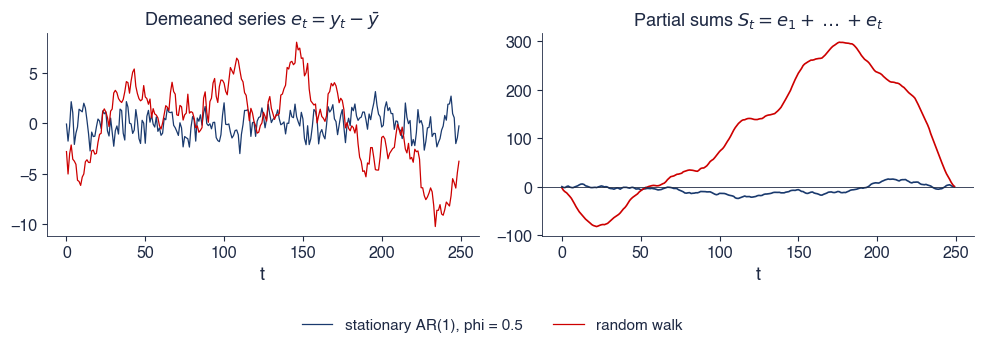

,det,T,ADF,ADF p,lags,PP,KPSS,verdict
"Romania real GDP, log",ct,106,-2.311535,0.427581,0,-2.192991,0.197924,I(1)
"Romania real GDP, growth",c,105,-10.769545,0.0,0,-10.878365,0.263065,I(0)
"Romania HICP, log",ct,260,-0.961364,0.949096,6,-0.883651,0.314494,I(1)
"Romania inflation, 12 months",c,260,-1.935718,0.315449,15,-2.309199,0.404027,inconclusive
"Romania inflation, change",c,259,-4.825128,0.000049,14,-11.313515,0.105162,I(0)
"EUR/RON, log",c,5353,-1.222734,0.66374,7,-1.151568,10.255245,I(1)
"EUR/RON, returns",c,5352,-27.424478,0.0,6,-60.823214,0.055252,I(0)
"BET, log price",ct,6671,-1.903364,0.652924,19,-2.348332,1.142908,I(1)
"BET, returns",c,6670,-16.503303,0.0,18,-74.550721,0.359518,I(0)
"S&P 500, log price",ct,6715,-2.081369,0.556513,34,-2.364688,2.281017,I(1)


In [9]:
def fig_kpss_sums(T=250, save_it=True):
    """KPSS: partial sums S_t of the demeaned series, for a stationary AR(1) (phi = 0.5) and for a random walk."""
    rng = np.random.default_rng(SEED + 6)
    e = rng.normal(size=T)
    ar = np.zeros(T)
    for t in range(1, T):
        ar[t] = 0.5 * ar[t - 1] + e[t]
    rw = np.cumsum(rng.normal(size=T))
    fig, ax = plt.subplots(1, 2, figsize=(10.0, 3.1))
    out = {}
    for x, c, lab in [(ar, st.MainBlue, 'stationary AR(1), phi = 0.5'), (rw, st.IDAred, 'random walk')]:
        S = np.cumsum(x - x.mean())
        k = kpss_test(x, 'c')
        ax[0].plot(x - x.mean(), color=c, lw=0.9, label=lab)
        ax[1].plot(S, color=c, lw=1.2, label='_nolegend_')
        out['ar' if c == st.MainBlue else 'rw'] = k
    ax[0].set_title('Demeaned series $e_t = y_t - \\bar y$')
    ax[1].set_title('Partial sums $S_t = e_1 + \\dots + e_t$')
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    for a in ax:
        a.set_xlabel('t')
    st.fig_legend_bottom(fig, ncol=2, y=-0.01)
    plt.tight_layout()
    save('tsa_ch3_kpss_sums', save_it)
    return out


def real_series():
    """The series of the unit-root table, with the deterministic terms of the test (ADF, PP, KPSS)."""
    g = 100 * np.log(ro_gdp().loc[GDP_START:])
    h = 100 * np.log(ro_hicp().loc['2005-01-01':])
    pi = ro_inflation()
    fx = 100 * np.log(load_close('eurron'))
    bet = 100 * np.log(load_close('bet', start=START))
    sp = 100 * np.log(load_close('sp500', start=START))
    us = 100 * np.log(us_gdp())
    nile = load_statsmodels('nile')
    return [('Romania real GDP, log', g, 'ct'), ('Romania real GDP, growth', g.diff(), 'c'),
            ('Romania HICP, log', h, 'ct'), ('Romania inflation, 12 months', pi, 'c'),
            ('Romania inflation, change', pi.diff(), 'c'),
            ('EUR/RON, log', fx, 'c'), ('EUR/RON, returns', fx.diff(), 'c'),
            ('BET, log price', bet, 'ct'), ('BET, returns', bet.diff(), 'c'),
            ('S&P 500, log price', sp, 'ct'), ('S&P 500, returns', sp.diff(), 'c'),
            ('US real GDP, log', us, 'ct'), ('US real GDP, growth', us.diff(), 'c'),
            ('Nile flow', nile, 'c')]


def unit_root_table():
    """ADF, PP and KPSS on the series of real_series(); saved as ch3_unit_root_tests.csv."""
    rows = {}
    for name, x, reg in real_series():
        x = x.dropna()
        a, p, k = adf_test(x, reg), pp_test(x, reg), kpss_test(x, reg)
        rows[name] = {'reg': reg, 'n': int(len(x)), 'adf': a, 'pp': p, 'kpss': k, 'verdict': verdict(a, k)}
    pd.DataFrame({k: {'deterministic': v['reg'], 'T': v['n'], 'ADF': v['adf']['stat'], 'ADF p': v['adf']['p'],
                      'ADF lags': v['adf']['lags'], 'PP': v['pp']['stat'], 'PP p': v['pp']['p'], 'KPSS': v['kpss']['stat'],
                      'KPSS 5% cv': v['kpss']['crit5'], 'ADF+KPSS': v['verdict']} for k, v in rows.items()}).T.to_csv(
        os.path.join(globals().get('OUT_DIR', globals().get('HERE', '.')), 'ch3_unit_root_tests.csv'), float_format='%.4f')
    return rows


fig_kpss_sums(save_it=False)
U = unit_root_table()
pd.DataFrame({k: {'det': v['reg'], 'T': v['n'], 'ADF': v['adf']['stat'], 'ADF p': v['adf']['p'], 'lags': v['adf']['lags'], 'PP': v['pp']['stat'], 'KPSS': v['kpss']['stat'], 'verdict': v['verdict']} for k, v in U.items()}).T

## 5. Structural breaks

- A stationary series around a broken mean; Zivot–Andrews on the Nile and on EUR/RON.

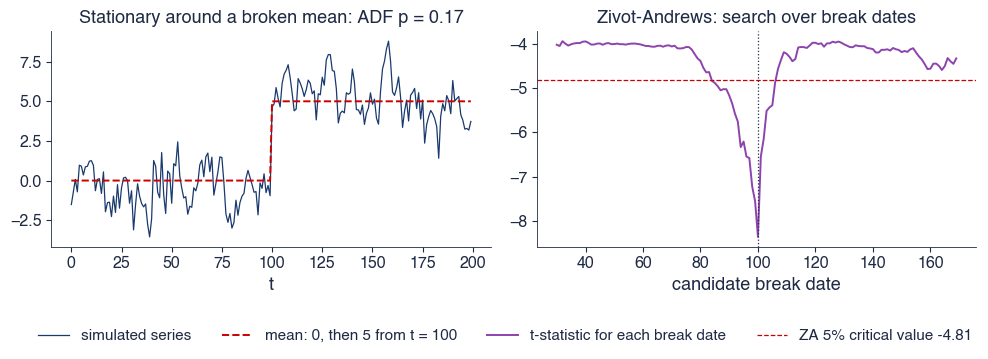

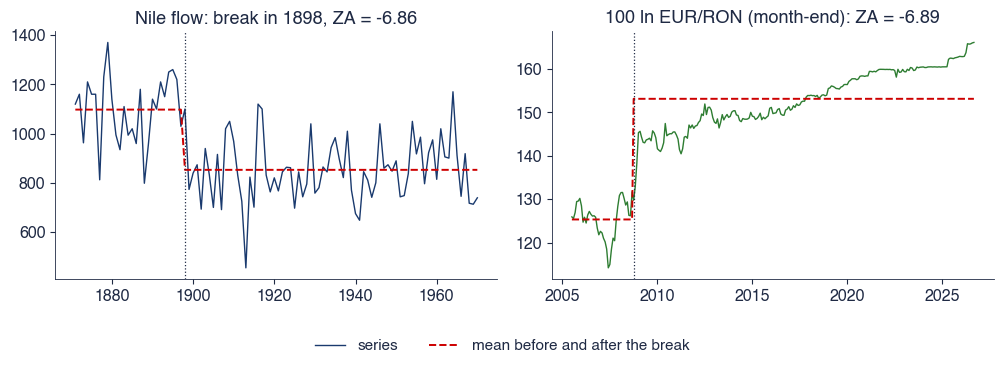

{'nile': {'za': {'stat': -6.859008939051496,
   'p': 1e-05,
   'crit5': -4.81067,
   'lags': 1,
   'break': '1898-01-01'},
  'adf': {'stat': -4.048705096914341,
   'p': 0.0011758879503871286,
   'lags': 1,
   'nobs': 98,
   'crit5': -2.891516256916761,
   'crit1': -3.4989097606014496,
   'crit10': -2.5827604414827157},
  'kpss': {'stat': 0.8691205593783892, 'p': 0.01, 'lags': 5, 'crit5': 0.463},
  'm0': 1097.6666666666667,
  'm1': 853.3972602739726,
  'n': 100},
 'eurron': {'za': {'stat': -6.8935914422927835,
   'p': 1e-05,
   'crit5': -4.81067,
   'lags': 1,
   'break': '2008-10-01'},
  'adf': {'stat': -1.456824134749029,
   'p': 0.5547515565297539,
   'lags': 1,
   'nobs': 253,
   'crit5': -2.873032730098417,
   'crit1': -3.4564641849494113,
   'crit10': -2.572894516864816},
  'kpss': {'stat': 2.064706668119944, 'p': 0.01, 'lags': 10, 'crit5': 0.463},
  'm0': 125.36399687908816,
  'm1': 153.12556845788208,
  'n': 255,
  'za_t': {'stat': -4.399850679800747,
   'p': 0.05096793573461751

In [10]:
def fig_breaks_sim(T=200, tb=100, delta=5.0, phi=0.6, R=2000, save_it=True):
    """Perron (1989): a stationary AR(1) around a mean that jumps by delta at tb looks like a unit root.
    One path with the ADF and Zivot-Andrews results; Monte Carlo rejection rate of the Dickey-Fuller test."""
    rng = np.random.default_rng(SEED + 7)
    u = random_walks(R, T + 100, rng, phi=phi)[:, 101:]
    step = delta * (np.arange(T) >= tb)
    y = u + step
    tau = df_tau_batch(np.column_stack([y[:, :1], y]), 'c')
    cv = mackinnoncrit(N=1, regression='c', nobs=T)[1]
    rej_break = float(np.mean(tau < cv))
    rej_nobreak = float(np.mean(df_tau_batch(np.column_stack([u[:, :1], u]), 'c') < cv))
    x = pd.Series(y[0], index=pd.RangeIndex(T))
    a, z = adf_test(x, 'c'), za_test(x, 'c')
    # Zivot-Andrews t-statistic for every candidate break date (no lags, constant + level dummy)
    dates = np.arange(int(0.15 * T), int(0.85 * T))
    tstats = []
    for b in dates:
        dy, ylag = np.diff(x.values), x.values[:-1]
        D = (np.arange(1, T) >= b).astype(float)
        X = np.column_stack([np.ones(T - 1), D, np.arange(1, T), ylag])
        tstats.append(sm.OLS(dy, X).fit().tvalues[3])
    fig, ax = plt.subplots(1, 2, figsize=(10.0, 3.2))
    ax[0].plot(x.index, x, color=st.MainBlue, lw=0.9, label='simulated series')
    ax[0].plot(x.index, step, color=st.IDAred, ls='--', label=f'mean: 0, then {delta:.0f} from t = {tb}')
    ax[0].set_title(f'Stationary around a broken mean: ADF p = {a["p"]:.2f}')
    ax[0].set_xlabel('t')
    ax[1].plot(dates, tstats, color=st.Purple, label='t-statistic for each break date')
    ax[1].axhline(z['crit5'], color=st.IDAred, ls='--', lw=0.9, label=f'ZA 5% critical value {z["crit5"]:.2f}')
    ax[1].axvline(dates[int(np.argmin(tstats))], color=st.DarkText, ls=':', lw=0.9)
    ax[1].set_title('Zivot-Andrews: search over break dates')
    ax[1].set_xlabel('candidate break date')
    st.fig_legend_bottom(fig, ncol=4, y=-0.01)
    plt.tight_layout()
    save('tsa_ch3_breaks_sim', save_it)
    return {'adf': a, 'za': z, 'rej_break': rej_break, 'rej_nobreak': rej_nobreak, 'best_date': int(dates[int(np.argmin(tstats))]),
            'min_t': float(np.min(tstats)), 'R': R}


def fig_breaks_real(save_it=True):
    """Zivot-Andrews (break in the level) on two series: the Nile flow (1871-1970) and the month-end EUR/RON rate."""
    nile = load_statsmodels('nile')
    fx = np.log(load_close('eurron')).resample('MS').last() * 100
    out = {}
    fig, ax = plt.subplots(1, 2, figsize=(10.2, 3.3))
    for a_, (name, x, c) in zip(ax, [('nile', nile, st.MainBlue), ('eurron', fx, st.Forest)]):
        z = za_test(x, 'c')
        b = pd.Timestamp(z['break'])
        m0, m1 = x[x.index < b].mean(), x[x.index >= b].mean()
        a_.plot(x.index, x, color=c, lw=1.0, label='series')
        a_.plot(x.index, np.where(x.index < b, m0, m1), color=st.IDAred, ls='--', label='mean before and after the break')
        a_.axvline(b, color=st.DarkText, ls=':', lw=0.9)
        out[name] = {'za': z, 'adf': adf_test(x, 'c'), 'kpss': kpss_test(x, 'c'), 'm0': float(m0), 'm1': float(m1),
                     'n': int(len(x))}
    ax[0].set_title(f"Nile flow: break in {out['nile']['za']['break'][:4]}, ZA = {out['nile']['za']['stat']:.2f}")
    ax[1].set_title(f"100 ln EUR/RON (month-end): ZA = {out['eurron']['za']['stat']:.2f}")
    years_axis(ax[0], 20)
    years_axis(ax[1], 5)
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch3_breaks_real', save_it)
    out['eurron']['za_t'] = za_test(fx, 't')
    out['eurron']['za_ct'] = za_test(fx, 'ct')
    return out


fig_breaks_sim(save_it=False)
fig_breaks_real(save_it=False)

## 6. An ARIMA model for Romanian GDP

- Identification, model choice by AICc (two samples), diagnostics, forecasts, over-differencing.

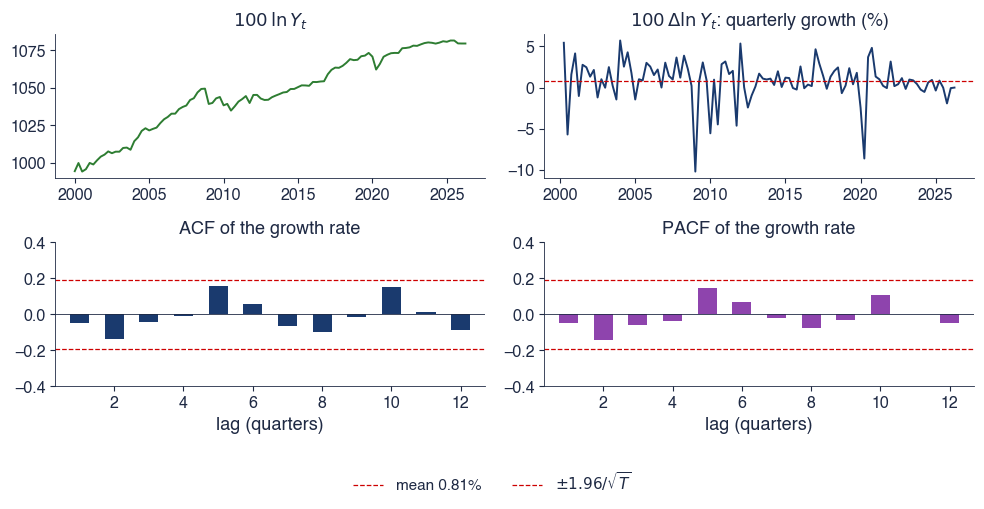

[0, 0] [2, 2]


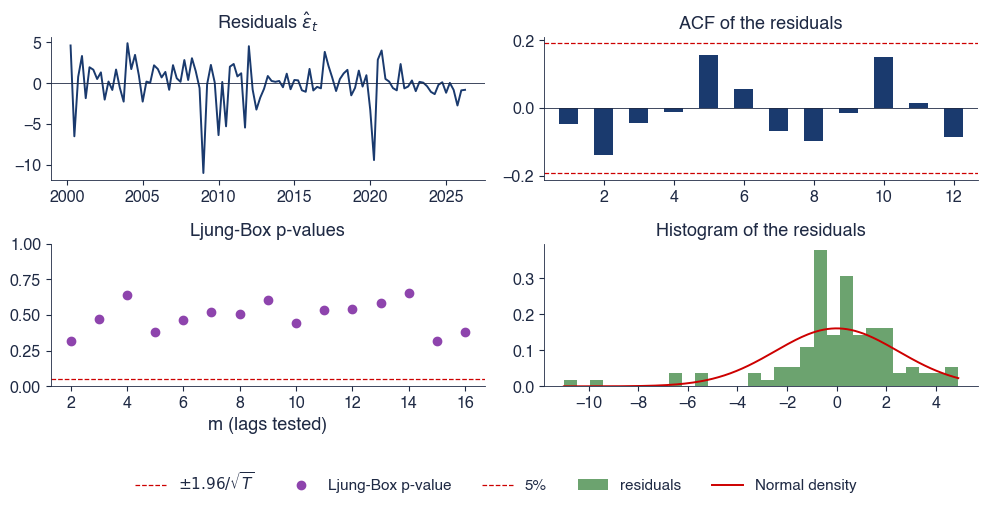

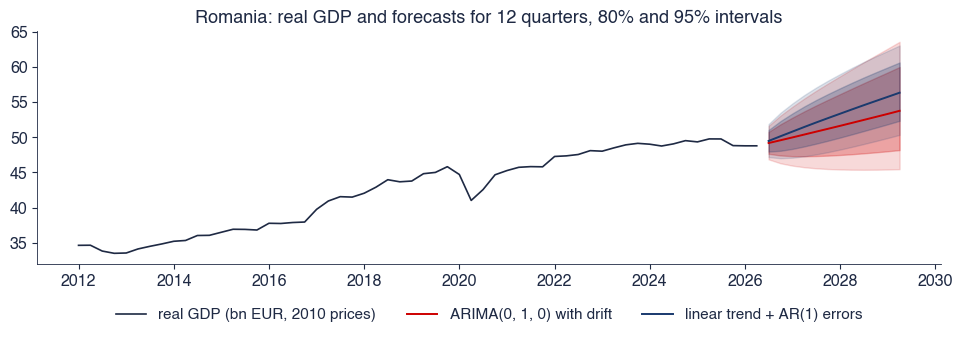

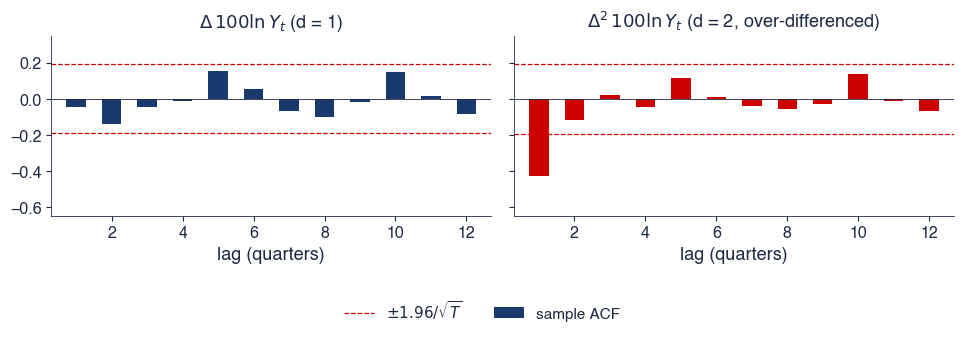

{'var1': 6.155274502822848,
 'var2': 12.803618788568874,
 'r1_d1': -0.04750881077572527,
 'r1_d2': -0.4255137261617417,
 'theta': -0.9874483034185322,
 'theta_se': 0.07986499730617488}

In [11]:
def fig_gdp_ident(nlags=12, save_it=True):
    """Romanian real GDP: 100 ln Y_t, its first difference (quarterly growth in %), ACF and PACF of the growth."""
    y = gdp_series()
    d = y.diff().dropna()
    fig, ax = plt.subplots(2, 2, figsize=(10.0, 4.6))
    ax[0, 0].plot(y.index.to_timestamp(), y, color=st.Forest)
    ax[0, 0].set_title(r'$100\,\ln Y_t$')
    ax[0, 1].plot(d.index.to_timestamp(), d, color=st.MainBlue)
    ax[0, 1].axhline(d.mean(), color=st.IDAred, ls='--', lw=0.9, label=f'mean {d.mean():.2f}%')
    ax[0, 1].set_title(r'$100\,\Delta\ln Y_t$: quarterly growth (%)')
    acf_bars(ax[1, 0], sample_acf(d, nlags), len(d), color=st.MainBlue, label='_nolegend_')
    ax[1, 0].set_title('ACF of the growth rate')
    acf_bars(ax[1, 1], sample_pacf(d, nlags), len(d), color=st.Purple, label='_nolegend_')
    ax[1, 1].set_title('PACF of the growth rate')
    for a in ax[1]:
        a.set_xlabel('lag (quarters)')
        a.set_ylim(-0.4, 0.4)
    for a in ax[0]:
        years_axis(a, 5)
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch3_gdp_ident', save_it)
    r, p = sample_acf(d, nlags), sample_pacf(d, nlags)
    worst = d.nsmallest(2)
    return {'n': int(len(y)), 'first': str(y.index[0]), 'last': str(y.index[-1]), 'mean': float(d.mean()), 'sd': float(d.std()),
            'r1': float(r[0]), 'r2': float(r[1]), 'p1': float(p[0]), 'p2': float(p[1]), 'band': 1.96 / np.sqrt(len(d)),
            'n_out': int(np.sum(np.abs(r) > 1.96 / np.sqrt(len(d)))), 'lb8': ljung_box(d, 8),
            'worst1': [str(worst.index[0]), float(worst.iloc[0])], 'worst2': [str(worst.index[1]), float(worst.iloc[1])]}


def gdp_models():
    """Model choice for 100 ln GDP: ARIMA(p,1,q) with drift, p, q <= 2, on 2000Q1-end and on 1995Q1-end."""
    out = {}
    for lab, start in [('main', GDP_START), ('full', '1995-01-01')]:
        y = gdp_series(start)
        g = arima_grid(y)
        allbest = min(g, key=lambda k: g[k]['aicc'])
        out[lab] = {'grid': {f'{p}{q}': v for (p, q), v in g.items()}, 'best': list(best_order(g)), 'best_any': list(allbest),
                    'n': int(len(y)), 'first': str(y.index[0])}
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            m = ARIMA(y, order=(allbest[0], 1, allbest[1]), trend='t').fit()
        out[lab]['best_any_params'] = {k: float(v) for k, v in m.params.items()}
        out[lab]['best_any_se'] = {k: float(v) for k, v in m.bse.items()}
        out[lab]['best_any_maroots'] = [float(abs(r)) for r in m.maroots]
        out[lab]['best_any_arroots'] = [float(abs(r)) for r in m.arroots]
    return out


def fig_gdp_diag(order=None, save_it=True):
    """Residual diagnostics of the chosen ARIMA for Romanian GDP: residuals, their ACF, Ljung-Box p-values, histogram."""
    order = order or gdp_order()
    m = gdp_fit(order)
    e = m.resid.iloc[1:]
    k = order[0] + order[2]
    fig, ax = plt.subplots(2, 2, figsize=(10.0, 4.6))
    ax[0, 0].plot(e.index.to_timestamp(), e, color=st.MainBlue)
    ax[0, 0].axhline(0, color=st.DarkText, lw=0.6)
    ax[0, 0].set_title('Residuals $\\hat\\varepsilon_t$')
    years_axis(ax[0, 0], 5)
    acf_bars(ax[0, 1], sample_acf(e, 12), len(e), color=st.MainBlue, label='_nolegend_')
    ax[0, 1].set_title('ACF of the residuals')
    ms = np.arange(max(k + 1, 2), 17)
    pv = [ljung_box(e, mm, k)['lb_p'] for mm in ms]
    ax[1, 0].plot(ms, pv, 'o', color=st.Purple, label='Ljung-Box p-value')
    ax[1, 0].axhline(0.05, color=BAND_COL, ls='--', lw=0.9, label='5%')
    ax[1, 0].set_ylim(0, 1)
    ax[1, 0].set_xlabel('m (lags tested)')
    ax[1, 0].set_title('Ljung-Box p-values')
    ax[1, 1].hist(e, bins=30, density=True, color=st.Forest, alpha=0.7, label='residuals')
    xx = np.linspace(e.min(), e.max(), 200)
    ax[1, 1].plot(xx, stats.norm.pdf(xx, e.mean(), e.std()), color=st.IDAred, label='Normal density')
    ax[1, 1].set_title('Histogram of the residuals')
    st.fig_legend_bottom(fig, ncol=5, y=-0.01)
    plt.tight_layout()
    save('tsa_ch3_gdp_diag', save_it)
    jb = stats.jarque_bera(e)
    return {'params': {kk: float(v) for kk, v in m.params.items()}, 'se': {kk: float(v) for kk, v in m.bse.items()},
            'sigma': float(np.sqrt(m.params['sigma2'])), 'lb8': ljung_box(e, 8, k), 'lb12': ljung_box(e, 12, k),
            'jb': float(jb.statistic), 'jb_p': float(jb.pvalue), 'kurt': float(stats.kurtosis(e, fisher=False)),
            'min': [str(e.idxmin()), float(e.min())], 'max': [str(e.idxmax()), float(e.max())], 'aicc': float(m.aicc),
            'order': list(order)}


def fig_gdp_forecast(order=None, H=12, save_it=True):
    """Forecasts of 100 ln GDP for H quarters: the chosen ARIMA with drift (difference-stationary) against a
    linear trend with AR(1) errors (trend-stationary), each with 80% and 95% intervals; back in bn EUR."""
    order = order or gdp_order()
    y = gdp_series()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        ds = ARIMA(y, order=order, trend='t').fit()
        ts = ARIMA(y, order=(1, 0, 0), trend='ct').fit()
    out = {}
    fig, ax = plt.subplots(figsize=(9.8, 3.6))
    hist = y.loc['2012Q1':]
    ax.plot(hist.index.to_timestamp(), np.exp(hist / 100) / 1000, color=st.DarkText, lw=1.2, label='real GDP (bn EUR, 2010 prices)')
    for lab, m, c in [('ds', ds, st.IDAred), ('ts', ts, st.MainBlue)]:
        f = m.get_forecast(H)
        mean = f.predicted_mean
        ci95, ci80 = f.conf_int(alpha=0.05), f.conf_int(alpha=0.20)
        x = mean.index.to_timestamp()
        name = f'ARIMA{order} with drift' if lab == 'ds' else 'linear trend + AR(1) errors'
        ax.plot(x, np.exp(mean / 100) / 1000, color=c, lw=1.4, label=name)
        ax.fill_between(x, np.exp(ci95.iloc[:, 0] / 100) / 1000, np.exp(ci95.iloc[:, 1] / 100) / 1000, color=c, alpha=0.15,
                        label='_nolegend_')
        ax.fill_between(x, np.exp(ci80.iloc[:, 0] / 100) / 1000, np.exp(ci80.iloc[:, 1] / 100) / 1000, color=c, alpha=0.25,
                        label='_nolegend_')
        w = (ci95.iloc[:, 1] - ci95.iloc[:, 0]).values / 2
        out[lab] = {'h1': float(mean.iloc[0]), 'h4': float(mean.iloc[3]), 'h12': float(mean.iloc[H - 1]),
                    'w1': float(w[0]), 'w4': float(w[3]), 'w8': float(w[7]), 'w12': float(w[H - 1]),
                    'level12': float(np.exp(mean.iloc[H - 1] / 100) / 1000),
                    'lo12': float(np.exp(ci95.iloc[H - 1, 0] / 100) / 1000), 'hi12': float(np.exp(ci95.iloc[H - 1, 1] / 100) / 1000),
                    'params': {k: float(v) for k, v in m.params.items()}, 'last_q': str(mean.index[-1])}
    ax.set_title(f'Romania: real GDP and forecasts for {H} quarters, 80% and 95% intervals')
    years_axis(ax, 2)
    st.legend_outside_bottom(ax, ncol=3, y=-0.13)
    plt.tight_layout()
    save('tsa_ch3_gdp_forecast', save_it)
    out['last'] = float(y.iloc[-1])
    out['last_level'] = float(np.exp(y.iloc[-1] / 100) / 1000)
    out['last_q'] = str(y.index[-1])
    return out


def fig_overdiff_gdp(nlags=12, save_it=True):
    """Over-differencing Romanian GDP: ACF of the growth rate and of its difference; an MA(1) fitted to the
    second difference has theta close to -1 (a unit root in the MA polynomial)."""
    y = gdp_series()
    d1, d2 = y.diff().dropna(), y.diff().diff().dropna()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        m = ARIMA(d2, order=(0, 0, 1), trend='n').fit()
    fig, ax = plt.subplots(1, 2, figsize=(9.8, 2.9), sharey=True)
    acf_bars(ax[0], sample_acf(d1, nlags), len(d1), color=st.MainBlue, label='sample ACF')
    acf_bars(ax[1], sample_acf(d2, nlags), len(d2), color=st.IDAred, label='_nolegend_')
    ax[0].set_title(r'$\Delta\,100\ln Y_t$ (d = 1)')
    ax[1].set_title(r'$\Delta^2\,100\ln Y_t$ (d = 2, over-differenced)')
    ax[0].set_ylim(-0.65, 0.35)
    for a in ax:
        a.set_xlabel('lag (quarters)')
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch3_overdiff_gdp', save_it)
    return {'var1': float(d1.var()), 'var2': float(d2.var()), 'r1_d1': float(sample_acf(d1, 1)[0]),
            'r1_d2': float(sample_acf(d2, 1)[0]), 'theta': float(m.params['ma.L1']), 'theta_se': float(m.bse['ma.L1'])}


fig_gdp_ident(save_it=False)
M = gdp_models()
print(M['main']['best'], M['full']['best_any'])
fig_gdp_diag(save_it=False)
fig_gdp_forecast(save_it=False)
fig_overdiff_gdp(save_it=False)

## 7. Forecast intervals

- Half-widths of 95% intervals from the $\psi$ weights; a worked ARIMA(1,1,0) example.

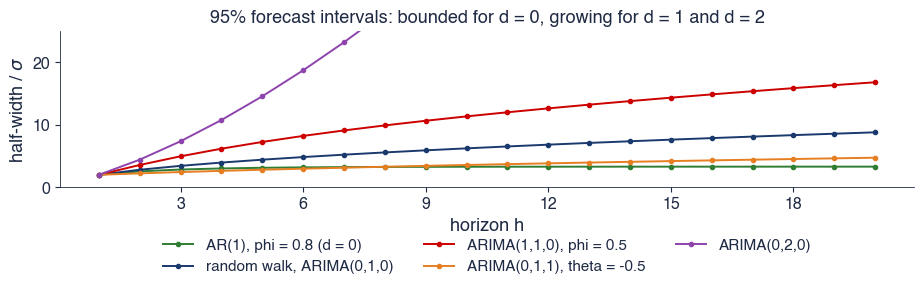

{'f': [111.0, 112.8, 113.88],
 'psi': [1.0, 1.6, 1.9600000000000004],
 'var': [4.0, 14.240000000000002, 29.606400000000008],
 'half': [3.92, 7.396241207532378, 10.664705633068362]}

In [12]:
def fig_interval_width(H=20, save_it=True):
    """Half-width of 95% forecast intervals (in units of sigma) against the horizon, for five models."""
    models = [('AR(1), phi = 0.8 (d = 0)', (0.8,), (), 0, st.Forest),
              ('random walk, ARIMA(0,1,0)', (), (), 1, st.MainBlue),
              ('ARIMA(1,1,0), phi = 0.5', (0.5,), (), 1, st.IDAred),
              ('ARIMA(0,1,1), theta = -0.5', (), (-0.5,), 1, st.Orange),
              ('ARIMA(0,2,0)', (), (), 2, st.Purple)]
    h = np.arange(1, H + 1)
    out = {}
    fig, ax = plt.subplots(figsize=(9.4, 3.3))
    for lab, ar, ma, d, c in models:
        psi = psi_weights(ar, ma, d, H)
        w = 1.96 * np.sqrt(np.cumsum(psi ** 2))
        ax.plot(h, w, 'o-', ms=3, color=c, label=lab)
        out[lab] = {'w1': float(w[0]), 'w4': float(w[3]), 'w20': float(w[-1]), 'psi': [float(v) for v in psi[:5]]}
    ax.set_xlabel('horizon h')
    ax.set_ylabel(r'half-width / $\sigma$')
    ax.set_title('95% forecast intervals: bounded for d = 0, growing for d = 1 and d = 2')
    ax.set_ylim(0, 25)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    st.legend_outside_bottom(ax, ncol=3, y=-0.24)
    plt.tight_layout()
    save('tsa_ch3_interval_width', save_it)
    return out


def arima110_by_hand(phi=0.6, y_T=108.0, dy_T=5.0, sigma=2.0, H=3):
    """Worked example: forecasts and 95% intervals of an ARIMA(1,1,0) without constant."""
    f, dy, y = [], dy_T, y_T
    for _ in range(H):
        dy = phi * dy
        y = y + dy
        f.append(y)
    psi = psi_weights((phi,), (), 1, H)
    var = sigma ** 2 * np.cumsum(psi ** 2)
    return {'f': f, 'psi': [float(v) for v in psi], 'var': [float(v) for v in var],
            'half': [float(1.96 * np.sqrt(v)) for v in var]}


fig_interval_width(save_it=False)
arima110_by_hand()

## 8. ARIMA in practice

- Romanian inflation with $d = 0$ and $d = 1$; EUR/RON against the random walk; US real GDP after 2007.

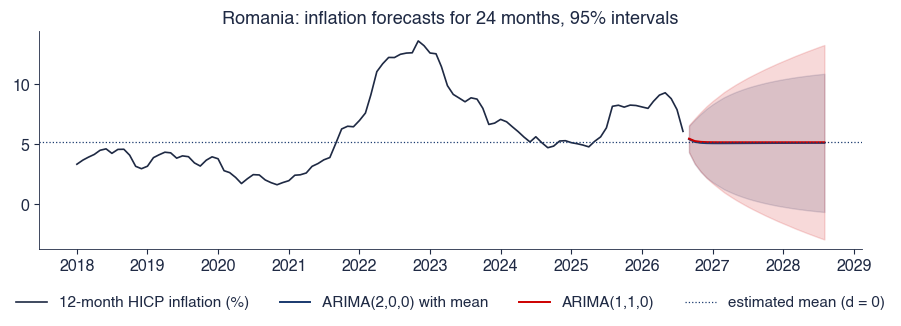

[2, 0, 0] [1, 1, 0] 0


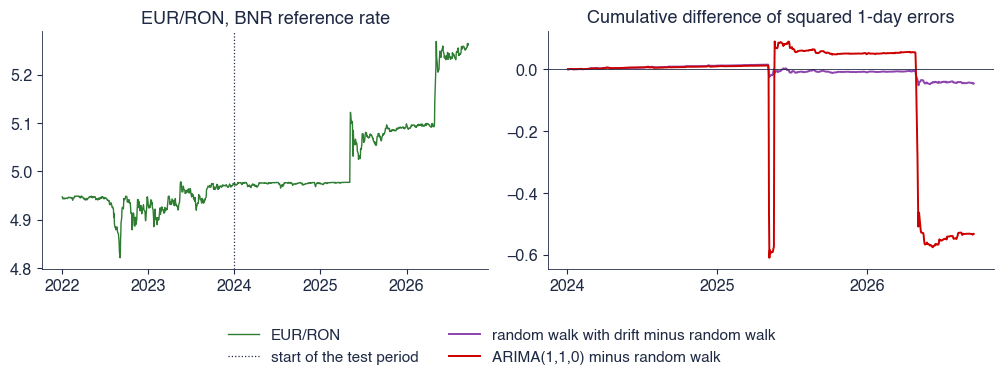

{'rw': 0.13295990602242985, 'drift': 0.13270563095493573, 'ar': 0.12997363682918592} {'rw': 0.6672346835935183, 'drift': 0.6468029349305998, 'ar': 0.6383709918365396}


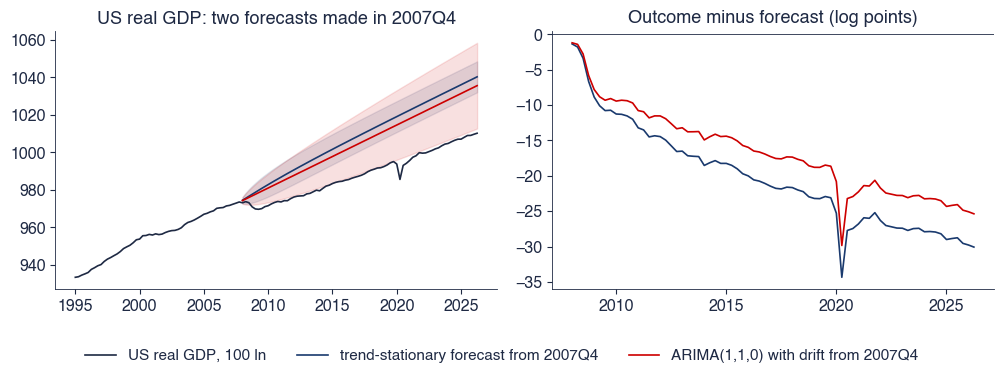

{'cut': '2007Q4',
 'H': 74,
 'last_q': '2026Q2',
 'ts': {'gap_end': -30.079764911865027,
  'gap_2009': -10.093143765275613,
  'covered_end': False,
  'half_end': 8.237572834089178},
 'ds': {'gap_end': -25.375540758910006,
  'gap_2009': -8.8259770845915,
  'covered_end': False,
  'half_end': 22.85611637389485}}

In [13]:
def fig_inflation_d(H=24, save_it=True):
    """Romanian 12-month HICP inflation since 2005: the best AR model with a mean (d = 0) against the best ARIMA
    with d = 1 (AICc, p <= 3, q <= 2), with 95% forecast intervals for H months; KPSS sequence (Hyndman-Khandakar)."""
    pi = monthly(ro_inflation())
    g0, g1 = arima_grid(pi, d=0, pmax=3, qmax=2, trend='c'), arima_grid(pi, d=1, pmax=3, qmax=2, trend='n')
    o0, o1 = best_order(g0), best_order(g1)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        m0 = ARIMA(pi, order=(o0[0], 0, o0[1]), trend='c').fit()
        m1 = ARIMA(pi, order=(o1[0], 1, o1[1]), trend='n').fit()
    fig, ax = plt.subplots(figsize=(9.8, 3.5))
    hist = pi.loc['2018-01':]
    ax.plot(hist.index.to_timestamp(), hist, color=st.DarkText, lw=1.2, label='12-month HICP inflation (%)')
    out = {'n': int(len(pi)), 'first': str(pi.index[0]), 'last': str(pi.index[-1]), 'lastv': float(pi.iloc[-1]),
           'mean': float(pi.mean()), 'max': float(pi.max()), 'maxd': str(pi.idxmax())}
    for lab, m, o, d, c in [('d0', m0, o0, 0, st.MainBlue), ('d1', m1, o1, 1, st.IDAred)]:
        f = m.get_forecast(H)
        ci = f.conf_int(alpha=0.05)
        x = f.predicted_mean.index.to_timestamp()
        ax.plot(x, f.predicted_mean, color=c, lw=1.4, label=f'ARIMA({o[0]},{d},{o[1]})' + (' with mean' if d == 0 else ''))
        ax.fill_between(x, ci.iloc[:, 0], ci.iloc[:, 1], color=c, alpha=0.15, label='_nolegend_')
        out[lab] = {'order': [o[0], d, o[1]], 'aicc': float(m.aicc), 'h12': float(f.predicted_mean.iloc[11]),
                    'h24': float(f.predicted_mean.iloc[H - 1]), 'lo24': float(ci.iloc[H - 1, 0]), 'hi24': float(ci.iloc[H - 1, 1]),
                    'lo12': float(ci.iloc[11, 0]), 'hi12': float(ci.iloc[11, 1]),
                    'params': {k: float(v) for k, v in m.params.items()}}
    ax.axhline(m0.params['const'], color=st.MainBlue, ls=':', lw=0.9, label='estimated mean (d = 0)')
    ax.set_title(f'Romania: inflation forecasts for {H} months, 95% intervals')
    years_axis(ax, 1)
    st.legend_outside_bottom(ax, ncol=4, y=-0.15)
    plt.tight_layout()
    save('tsa_ch3_inflation_d', save_it)
    # Hyndman-Khandakar choice of d: KPSS at 5% on the level, then on the difference
    k0 = kpss_test(pi, 'c')
    k1 = kpss_test(pi.diff().dropna(), 'c')
    out['kpss0'], out['kpss1'] = k0, k1
    out['adf0'], out['adf1'] = adf_test(pi, 'c'), adf_test(pi.diff().dropna(), 'c')
    out['d_hk'] = 0 if k0['stat'] <= k0['crit5'] else (1 if k1['stat'] <= k1['crit5'] else 2)
    out['grid0'] = {f'{p}{q}': v for (p, q), v in g0.items()}
    out['grid1'] = {f'{p}{q}': v for (p, q), v in g1.items()}
    return out


def fig_eurron_forecast(split='2024-01-01', save_it=True):
    """EUR/RON (BNR), 100 ln of the daily rate: one-day-ahead forecasts from the start of 2024 by the random walk,
    the random walk with drift and an ARIMA(1,1,0) (parameters estimated once, on the data before 2024);
    root mean squared errors (RMSE) at horizons of 1 and 20 days."""
    y = 100 * np.log(load_close('eurron'))
    d = y.diff().dropna()
    train = d.loc[:pd.Timestamp(split) - pd.Timedelta(days=1)]
    mu = float(train.mean())
    X = np.column_stack([np.ones(len(train) - 1), train.values[:-1]])
    c, phi = np.linalg.lstsq(X, train.values[1:], rcond=None)[0]
    test = d.loc[split:]
    prev = d.shift(1).loc[split:]
    e_rw = test.values
    e_dr = test.values - mu
    e_ar = test.values - (c + phi * prev.values)
    rmse = lambda e: float(np.sqrt(np.mean(np.asarray(e) ** 2)))
    # 20-day-ahead forecasts of the level, non-overlapping origins
    lev = y.loc[split:]
    idx = np.arange(0, len(lev) - 20, 20)
    e20 = {'rw': [], 'drift': [], 'ar': []}
    for i in idx:
        pos = y.index.get_loc(lev.index[i])
        base, last_d = y.iloc[pos], d.iloc[pos - 1]
        target = y.iloc[pos + 20]
        ar_path, dd = 0.0, last_d
        for _ in range(20):
            dd = c + phi * dd
            ar_path += dd
        e20['rw'].append(target - base)
        e20['drift'].append(target - base - 20 * mu)
        e20['ar'].append(target - base - ar_path)
    fig, ax = plt.subplots(1, 2, figsize=(10.2, 3.2))
    lv = np.exp(y.loc['2022-01-01':] / 100)
    ax[0].plot(lv.index, lv, color=st.Forest, lw=1.0, label='EUR/RON')
    ax[0].axvline(pd.Timestamp(split), color=st.DarkText, ls=':', lw=0.9, label='start of the test period')
    ax[0].set_title('EUR/RON, BNR reference rate')
    years_axis(ax[0], 1)
    cum = pd.DataFrame({'random walk with drift minus random walk': np.cumsum(e_dr ** 2 - e_rw ** 2),
                        'ARIMA(1,1,0) minus random walk': np.cumsum(e_ar ** 2 - e_rw ** 2)}, index=test.index)
    ax[1].plot(cum.index, cum.iloc[:, 0], color=st.Purple, label=cum.columns[0])
    ax[1].plot(cum.index, cum.iloc[:, 1], color=st.IDAred, label=cum.columns[1])
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    ax[1].set_title('Cumulative difference of squared 1-day errors')
    years_axis(ax[1], 1)
    st.fig_legend_bottom(fig, ncol=2, y=-0.01)
    plt.tight_layout()
    save('tsa_ch3_eurron_forecast', save_it)
    return {'mu': mu, 'c': float(c), 'phi': float(phi), 'n_train': int(len(train)), 'n_test': int(len(test)),
            'rmse1': {'rw': rmse(e_rw), 'drift': rmse(e_dr), 'ar': rmse(e_ar)},
            'rmse20': {k: rmse(v) for k, v in e20.items()}, 'n20': int(len(idx)), 'first': str(y.index[0])[:10],
            'last': str(y.index[-1])[:10], 'fx_split': float(np.exp(y.loc[:split].iloc[-1] / 100)),
            'fx_last': float(np.exp(y.iloc[-1] / 100))}


def fig_us_gdp(cut='2007Q4', save_it=True):
    """US real GDP (100 ln): a trend-stationary model (linear trend + AR(2) errors) and a difference-stationary model
    (ARIMA(1,1,0) with drift) estimated up to 2007Q4, forecast to the end of the data, against the outcome."""
    y = quarterly(100 * np.log(us_gdp()))
    tr = y.loc[:cut]
    H = len(y.loc[cut:]) - 1
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        ts = ARIMA(tr, order=(2, 0, 0), trend='ct').fit()
        ds = ARIMA(tr, order=(1, 1, 0), trend='t').fit()
    fts, fds = ts.get_forecast(H), ds.get_forecast(H)
    fig, ax = plt.subplots(1, 2, figsize=(10.2, 3.4))
    view = y.loc['1995Q1':]
    ax[0].plot(view.index.to_timestamp(), view, color=st.DarkText, lw=1.2, label='US real GDP, 100 ln')
    out = {'cut': cut, 'H': H, 'last_q': str(y.index[-1])}
    for lab, f, c, name in [('ts', fts, st.MainBlue, 'trend-stationary forecast from 2007Q4'),
                            ('ds', fds, st.IDAred, 'ARIMA(1,1,0) with drift from 2007Q4')]:
        m = f.predicted_mean
        ci = f.conf_int(alpha=0.05)
        x = m.index.to_timestamp()
        ax[0].plot(x, m, color=c, lw=1.2, label=name)
        ax[0].fill_between(x, ci.iloc[:, 0], ci.iloc[:, 1], color=c, alpha=0.12, label='_nolegend_')
        gap = y.loc[m.index] - m
        ax[1].plot(x, gap, color=c, lw=1.2, label='_nolegend_')
        out[lab] = {'gap_end': float(gap.iloc[-1]), 'gap_2009': float(gap.loc['2009Q2']), 'covered_end':
                    bool(ci.iloc[-1, 0] <= y.iloc[-1] <= ci.iloc[-1, 1]), 'half_end': float((ci.iloc[-1, 1] - ci.iloc[-1, 0]) / 2)}
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    ax[1].set_title('Outcome minus forecast (log points)')
    ax[0].set_title('US real GDP: two forecasts made in 2007Q4')
    for a in ax:
        years_axis(a, 5)
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch3_us_gdp', save_it)
    return out


inf = fig_inflation_d(save_it=False)
print(inf['d0']['order'], inf['d1']['order'], inf['d_hk'])
fx = fig_eurron_forecast(save_it=False)
print(fx['rmse1'], fx['rmse20'])
fig_us_gdp(save_it=False)

## Exercises

1. Run `adf_test` and `kpss_test` on the DAX log price (`load_close('dax')`) and on its returns.
2. Repeat the Romanian GDP model choice with BIC instead of AICc: is the chosen model the same?
3. Change the break size `delta` in `fig_breaks_sim` to 2 and to 8: how does the ADF rejection rate change?